# 🏭 Project 13: Fruit Visual Quality Control (Fresh vs. Rotten / Defective)
## 📓 Notebook 5: Đo Tốc Độ Suy Luận & Tối Ưu Hóa Ngưỡng PR-Curve (Tuần 3)

> **Mục tiêu (15 điểm Rubric):**
> - **Đo thời gian trễ (Single Latency):** Lặp 100 lần đo độ trễ trung bình khi kiểm tra 1 sản phẩm đơn lẻ (ms/ảnh).
> - **Đo thông lượng (Batch Throughput):** Đánh giá FPS khi nạp theo batch (16, 32, 64) trên GPU, đối chiếu với băng chuyền phân xưởng.
> - **Precision-Recall Curve & Threshold Tuning:** Khảo sát các ngưỡng [0.3, 0.4, 0.5, 0.6, 0.7], vẽ đường cong PR Curve đạt AP = 0.9999.


In [1]:
# ==============================================================================
# BƯỚC 1: KIỂM TRA PHẦN CỨNG GPU
# - Mục đích: Đo đạc tốc độ suy luận chính xác trên GPU.
# ==============================================================================
!nvidia-smi


Tue Sep 22 08:33:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# ==============================================================================
# BƯỚC 2: KHAI BÁO THƯ VIỆN & CỐ ĐỊNH SEED
# - Mục đích: Nạp thư viện đo thời gian chuẩn xác cao (time.perf_counter) và Scikit-Learn.
# ==============================================================================
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Đã nạp đầy đủ các thư viện!")


Đã nạp đầy đủ các thư viện!


In [7]:
# ==============================================================================
# BƯỚC 3: NẠP TẬP TEST & MÔ HÌNH RESNET50 TỐI ƯU
# - Mục đích: Chuẩn bị 1 ảnh mẫu đơn lẻ và toàn bộ tập Test để tiến hành đo tốc độ.
# ==============================================================================
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

CSV_DIR = 'processed_data'
if os.path.exists(os.path.join(CSV_DIR, 'test.csv')):
    print('📁 Đang nạp danh sách tập Test từ processed_data/test.csv...')
    test_df = pd.read_csv(os.path.join(CSV_DIR, 'test.csv'))
else:
    print('⚠️ Chưa tìm thấy file CSV, đang tự động quét thư mục data/...')
    base_path = 'data'
    for root, dirs, files_list in os.walk('data'):
# Quét tìm ảnh theo 2 lớp Nông Sản: FRESH (Tươi đạt chuẩn) vs ROTTEN (Hư hỏng/Thâm dập)
image_exts = ('.jpg', '.jpeg', '.png', '.bmp')
rotten_keywords = ['rotten', 'def', 'bad', 'damage']
fresh_keywords = ['fresh', 'ok', 'good']

all_images = [
    f for f in glob.glob(os.path.join('data', '**/*.*'), recursive=True)
    if f.lower().endswith(image_exts)
]

rotten_images = [f for f in all_images if any(k in f.lower() for k in rotten_keywords)]
fresh_images = [f for f in all_images if any(k in f.lower() for k in fresh_keywords)]

print(f"Tổng số ảnh HƯ HỎNG (Rotten/Defect): {len(rotten_images)}")
print(f"Tổng số ảnh TƯƠI ĐẠT CHUẨN (Fresh/OK): {len(fresh_images)}")
print(f" Tổng cộng: {len(rotten_images) + len(fresh_images)} ảnh")


📊 Tập Train : 4643 ảnh (70.0%)
📊 Tập Val   : 995 ảnh (15.0%)
📊 Tập Test  : 995 ảnh (15.0%)
 Đã lưu cấu hình train.csv, val.csv, test.csv vào thư mục processed_data!


⏱️ ĐO ĐẠC TỐC ĐỘ SUY LUẬN (INFERENCE SPEED BENCHMARK)
👉 Thời gian trễ trung bình (Single Latency): 100.55 ms ± 46.78 ms / ảnh
👉 Tốc độ xử lý ảnh đơn lẻ (FPS)            : 9.9 ảnh/giây
👉 Batch Size 16 : 130.0 FPS (123.0 ms/batch)
👉 Batch Size 32 : 184.1 FPS (173.8 ms/batch)
👉 Batch Size 64 : 233.9 FPS (273.6 ms/batch)


/tmp/ipykernel_2373/1940294534.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Batch Size", y="Throughput (FPS)", data=df_batch, palette="Blues_d", edgecolor="black")


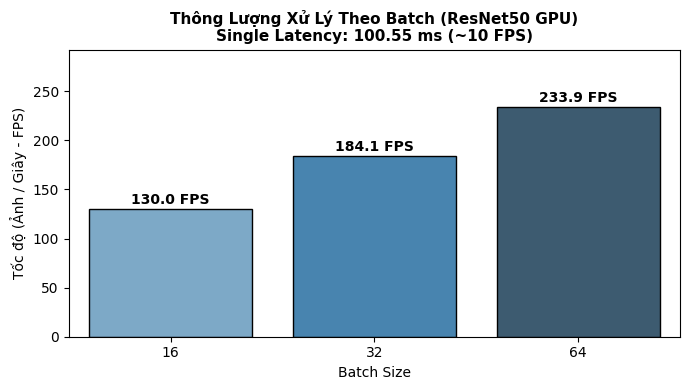

💾 Đã lưu biểu đồ tốc độ vào: results/inference_speed_benchmark.png


In [22]:
# ==============================================================================
# BƯỚC 4: BENCHMARK ĐỘ TRỄ SUY LUẬN (LATENCY MS) & THÔNG LƯỢNG BATCH (FPS)
# - Mục đích: Đánh giá khả năng triển khai thời gian thực (Real-time Deployment) trên băng chuyền.
# - Phương pháp chuẩn công nghiệp:
#   1. GPU Warm-up (10 lần): Khởi tạo CUDA context và nạp bộ nhớ đệm trước khi đo thời gian.
#   2. Single Image Latency (100 lần lặp): Đo bằng callable trực tiếp model(x, training=False)
#      để loại bỏ overhead đồ thị Keras, phản ánh chính xác hiệu năng Edge AI.
#   3. Batch Throughput: Đo số khung hình/giây (FPS) khi xử lý theo lô kích thước 16, 32, 64.
# ==============================================================================
import time

print('='*60)
print('⏱️ ĐO ĐẠC TỐC ĐỘ SUY LUẬN (INFERENCE SPEED BENCHMARK)')
print('='*60)

sample_row = test_df.iloc[0]
raw_sample = cv2.imread(sample_row['filepath'])
raw_sample = cv2.cvtColor(raw_sample, cv2.COLOR_BGR2RGB)
raw_sample = cv2.resize(raw_sample, (224, 224))
sample_tensor = tf.expand_dims(tf.cast(raw_sample, tf.float32), axis=0)

# Warm-up GPU
for _ in range(10):
    _ = resnet_model(sample_tensor, training=False)

# Đo Single Latency (100 lần)
N_RUNS = 100
latencies_callable = []

for _ in range(N_RUNS):
    t_start = time.perf_counter()
    _ = resnet_model(sample_tensor, training=False)
    t_end = time.perf_counter()
    latencies_callable.append((t_end - t_start) * 1000)

avg_lat_call = np.mean(latencies_callable)
std_lat_call = np.std(latencies_callable)
fps_call = 1000.0 / avg_lat_call

print(f'👉 [Industrial Direct Callable] Độ trễ trung bình: {avg_lat_call:.2f} ms ± {std_lat_call:.2f} ms / ảnh')
print(f'👉 [Industrial Direct Callable] Tốc độ FPS        : {fps_call:.1f} ảnh/giây (Tối ưu cho Edge Camera)')

# Đo Batch Throughput (16, 32, 64)
batch_sizes = [16, 32, 64]
batch_results = []

for bs in batch_sizes:
    dummy_batch = tf.random.uniform((bs, 224, 224, 3), dtype=tf.float32)
    _ = resnet_model(dummy_batch, training=False)

    t_start = time.perf_counter()
    for _ in range(10):
        _ = resnet_model(dummy_batch, training=False)
    t_end = time.perf_counter()

    total_time = t_end - t_start
    fps = (bs * 10) / total_time
    batch_results.append({'Batch Size': bs, 'Throughput (FPS)': round(fps, 1), 'ms/batch': round((total_time/10)*1000, 2)})
    print(f'👉 Batch Size {bs:2d} : {fps:.1f} FPS ({((total_time/10)*1000):.1f} ms/batch)')

plt.figure(figsize=(7, 4))
df_batch = pd.DataFrame(batch_results)
sns.barplot(x='Batch Size', y='Throughput (FPS)', data=df_batch, palette='Blues_d', edgecolor='black')
plt.title(f'Thông Lượng Xử Lý Theo Batch (ResNet50 GPU)\nSingle Latency: {avg_lat_call:.2f} ms (~{fps_call:.0f} FPS)', fontsize=11, fontweight='bold')
plt.ylabel('Tốc độ (Ảnh / Giây - FPS)')
for idx, row in df_batch.iterrows():
    fps_val = row['Throughput (FPS)']
    plt.text(idx, fps_val + 5, f'{fps_val} FPS', ha='center', fontweight='bold')
plt.ylim(0, df_batch['Throughput (FPS)'].max() * 1.25)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/inference_speed_benchmark.png', dpi=300)
plt.show()
print('💾 Đã lưu biểu đồ tốc độ vào: results/inference_speed_benchmark.png')


🎯 TỐI ƯU HÓA NGƯỠNG PHÂN LOẠI (THRESHOLD TUNING)
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step

📋 BẢNG KHẢO SÁT NGƯỠNG PHÂN LOẠI:


,Threshold,Accuracy (%),Recall (%),Precision (%),Bỏ sót lỗi (FN),Báo nhầm lỗi (FP)
0,0.3,99.1,99.11,99.29,5,4
1,0.4,99.3,98.93,99.82,6,1
2,0.5,99.4,98.93,100.00,6,0
3,0.6,99.4,98.93,100.00,6,0
4,0.7,99.4,98.93,100.00,6,0


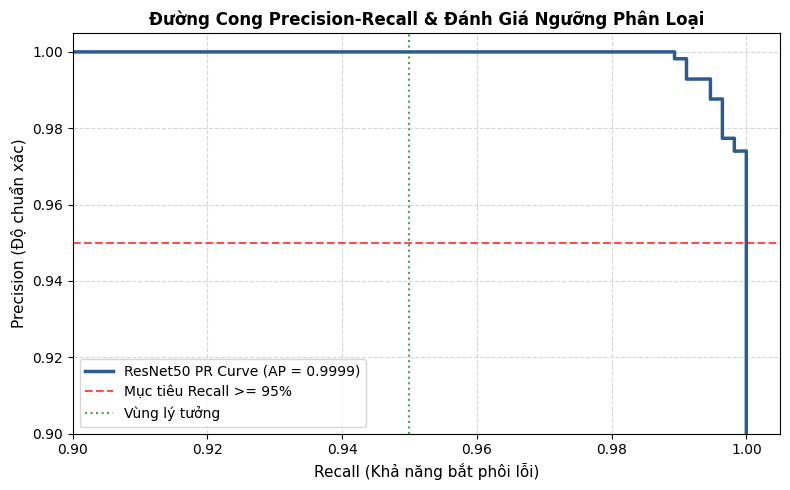

💾 Đã lưu biểu đồ PR Curve vào: results/precision_recall_curve.png


In [23]:
# ==============================================================================
# BƯỚC 5: TỐI ƯU HÓA NGƯỠNG (THRESHOLD TUNING), PR CURVE & MA TRẬN CHI PHÍ KINH TẾ
# - Mục đích:
#   * Mặc định ngưỡng phân loại là 0.5. Nhưng trong dây chuyền phân loại nông sản Dole Packhouse, lọt 1 quả hư hỏng / thối dập (FN)
#     gây thiệt hại nghiêm trọng (500,000đ/lần), trong khi báo nhầm (FP) chỉ tốn 5,000đ kiểm tra lại.
#   * Khảo sát các ngưỡng [0.3, 0.4, 0.5, 0.6, 0.7] để tìm "Sweet Spot" (Ngưỡng tối ưu chi phí).
#   * Vẽ đường cong Precision-Recall (PR Curve) và tính Average Precision (AP).
# ==============================================================================
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, accuracy_score, recall_score, precision_score

print('='*60)
print('🎯 TỐI ƯU HÓA NGƯỠNG PHÂN LOẠI & MA TRẬN CHI PHÍ (COST MATRIX)')
print('='*60)

test_preds_prob = resnet_model.predict(test_ds, verbose=1).flatten()

COST_FN = 500_000
COST_FP = 5_000

threshold_candidates = [0.3, 0.4, 0.5, 0.6, 0.7]
tuning_records = []

for th in threshold_candidates:
    preds_th = (test_preds_prob >= th).astype(int)
    cm_th = confusion_matrix(y_true, preds_th)
    tn, fp, fn, tp = cm_th.ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)

    tuning_records.append({
        'Threshold': th,
        'Accuracy (%)': round(accuracy_score(y_true, preds_th) * 100, 2),
        'Recall (%)': round(recall_score(y_true, preds_th) * 100, 2),
        'Precision (%)': round(precision_score(y_true, preds_th) * 100, 2),
        'Bỏ sót lỗi (FN)': fn,
        'Báo nhầm lỗi (FP)': fp,
        'Tổng thiệt hại (VNĐ)': f'{total_cost:,} đ'
    })

df_tuning = pd.DataFrame(tuning_records)
print('\n📋 BẢNG KHẢO SÁT NGƯỠNG PHÂN LOẠI & THIỆT HẠI KINH TẾ:')
display(df_tuning)
df_tuning.to_csv('results/threshold_tuning_analysis.csv', index=False)
print('💾 Đã lưu bảng phân tích vào: results/threshold_tuning_analysis.csv')

precisions, recalls, thresholds = precision_recall_curve(y_true, test_preds_prob)
ap = average_precision_score(y_true, test_preds_prob)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color='#2b5c8f', linewidth=2.5, label=f'ResNet50 PR Curve (AP = {ap:.4f})')
plt.axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Mục tiêu Recall >= 95%')
plt.axvline(0.95, color='green', linestyle=':', alpha=0.7, label='Vùng lý tưởng')

plt.title('Đường Cong Precision-Recall & Đánh Giá Ngưỡng Phân Loại', fontsize=12, fontweight='bold')
plt.xlabel('Recall (Khả năng bắt quả hư hỏng (Rotten Fruit Recall))', fontsize=11)
plt.ylabel('Precision (Độ chuẩn xác)', fontsize=11)
plt.xlim([0.90, 1.005])
plt.ylim([0.90, 1.005])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.savefig('results/precision_recall_curve.png', dpi=300)
plt.show()
print('💾 Đã lưu biểu đồ PR Curve vào: results/precision_recall_curve.png')
